In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import nltk
from nltk.stem.porter import PorterStemmer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [2]:
file_path = 'data/steam_games.csv'
nltk.download('stopwords')
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
#print(f"stopwords {list(stop_words)[:100]}")

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/felipecarpes/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [3]:
def read_dataset(file_path):

    if not os.path.exists(file_path):
        print("ERRO: Arquivo de dados não encontrado!")
        return None

    df_complete = pd.read_csv(file_path,nrows=2000)
    
    return df_complete

In [4]:
def clean_text(text):
    porter = PorterStemmer()
    text = str(text)
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[^a-zA-Z\s]', ' ', text)
    text = text.lower()
    tokens = word_tokenize(text)
    tokens_clean = [word for word in tokens if word not in stop_words]
    tokens_stemmed=[porter.stem(word) for word in tokens_clean]
    return " ".join(tokens_stemmed)

In [5]:
df_bruto = read_dataset(file_path)

if df_bruto is not None:

    # Limpando o arquivo, selecionando colunas que podem ser utilizadas
    important = [
        'appid', 'name', 'genres', 'description', 'short_description'
    ]
    df = df_bruto[important].copy()
    display(df.head())

,appid,name,genres,description,short_description
0,10,Counter-Strike,Action,Play the world's number 1 online action game. ...,Play the world's number 1 online action game. ...
1,20,Team Fortress Classic,Action,One of the most popular online action games of...,One of the most popular online action games of...
2,30,Day of Defeat,Action,Enlist in an intense brand of Axis vs. Allied ...,Enlist in an intense brand of Axis vs. Allied ...
3,40,Deathmatch Classic,Action,Enjoy fast-paced multiplayer gaming with Death...,Enjoy fast-paced multiplayer gaming with Death...
4,50,Half-Life: Opposing Force,Action,Return to the Black Mesa Research Facility as ...,Return to the Black Mesa Research Facility as ...


In [6]:
game_descriptions_clean = df['description'].apply(clean_text)
#print(game_descriptions_clean.iloc[9])

In [7]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer(max_df=0.6,min_df=10)
tfidf_matrix = vectorizer.fit_transform(game_descriptions_clean)
print(f"Formato da matriz: {tfidf_matrix.shape}")

Formato da matriz: (2000, 3089)


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline

#teste de vizualizacao
reuzindo_para = 1000

# ler o artigo de SVD pra conferir essa seed
seed = 42 

#svd = TruncatedSVD(n_components = reuzindo_para, random_state = seed)
#trecho de código de https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
lsa_pipeline = make_pipeline(TruncatedSVD(n_components=1000, random_state=42), 
                              Normalizer(copy=False))
lsa=lsa_pipeline[0]
# Aplica tudo de uma vez na sua matriz TF-IDF
final_matrix = lsa_pipeline.fit_transform(tfidf_matrix)
#final_matrix = svd.fit_transform(tfidf_matrix)

print(f"original: {tfidf_matrix.shape}")
print(f"reduzido: {final_matrix.shape}")

original: (2000, 3089)
reduzido: (2000, 1000)


In [ ]:
fig = plt.figure(figsize=(7, 5))
plt.plot([i for i in range(1, lsa.n_components + 1)], np.cumsum(lsa.explained_variance_ratio_))
plt.xlabel(r'$k$ - Número de componentes principais')
plt.ylabel(r'$f(k)$ - Fração cumulativa da variância explicada');

In [ ]:
from sklearn.cluster import KMeans
from sklearn import cluster, datasets
inertia = []

for i in range(1, 50):
  km = cluster.KMeans(n_clusters = i,init='k-means++')
  km.fit(final_matrix)
  inertia.append(km.inertia_)

plt.scatter(range(1, 50), inertia)
_ = plt.ylabel("Função Objetivo")
_ = plt.xlabel(r"$k$")

In [18]:
# Authors: The scikit-learn developers
# SPDX-License-Identifier: BSD-3-Clause

import matplotlib.cm as cm
import matplotlib.pyplot as plt
import numpy as np

from sklearn.metrics import silhouette_samples, silhouette_score
#plota distribuição de dados de acordo com o valor do coeficiente de silhueta
def visualize_silhouette_plot(k_init,k_final):
    range_cluster=range(k_init, k_final)

    for n_clusters in range_cluster:
        # Create a subplot with 1 row and 2 columns
        fig, (ax1, ax2) = plt.subplots(1, 2)
        fig.set_size_inches(18, 7)

        # The 1st subplot is the silhouette plot
        # The silhouette coefficient can range from -1, 1 but in this example all
        # lie within [-0.1, 1]
        ax1.set_xlim([-0.1, 1])
        # The (n_clusters+1)*10 is for inserting blank space between silhouette
        # plots of individual clusters, to demarcate them clearly.
        ax1.set_ylim([0, len(final_matrix) + (n_clusters + 1) * 10])

        # Initialize the clusterer with n_clusters value and a random generator
        # seed of 10 for reproducibility.
        clusterer = KMeans(n_clusters=n_clusters, random_state=10,init='k-means++')
        cluster_labels = clusterer.fit_predict(final_matrix)

        # The silhouette_score gives the average value for all the samples.
        # This gives a perspective into the density and separation of the formed
        # clusters
        silhouette_avg = silhouette_score(final_matrix, cluster_labels)
        print(
            "For n_clusters =",
            n_clusters,
            "The average silhouette_score is :",
            silhouette_avg,
        )

        # Compute the silhouette scores for each sample
        sample_silhouette_values = silhouette_samples(final_matrix, cluster_labels)

        y_lower = 10
        for i in range(n_clusters):
            # Aggregate the silhouette scores for samples belonging to
            # cluster i, and sort them
            ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]

            ith_cluster_silhouette_values.sort()

            size_cluster_i = ith_cluster_silhouette_values.shape[0]
            y_upper = y_lower + size_cluster_i

            color = cm.nipy_spectral(float(i) / n_clusters)
            ax1.fill_betweenx(
                np.arange(y_lower, y_upper),
                0,
                ith_cluster_silhouette_values,
                facecolor=color,
                edgecolor=color,
                alpha=0.7,
            )

            # Label the silhouette plots with their cluster numbers at the middle
            ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))

            # Compute the new y_lower for next plot
            y_lower = y_upper + 10  # 10 for the 0 samples

        ax1.set_title("The silhouette plot for the various clusters.")
        ax1.set_xlabel("The silhouette coefficient values")
        ax1.set_ylabel("Cluster label")

        # The vertical line for average silhouette score of all the values
        ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

        ax1.set_yticks([])  # Clear the yaxis labels / ticks
        ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

        # 2nd Plot showing the actual clusters formed
        colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
        ax2.scatter(
            final_matrix[:, 0], final_matrix[:, 1], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k"
        )

        # Labeling the clusters
        centers = clusterer.cluster_centers_
        # Draw white circles at cluster centers
        ax2.scatter(
            centers[:, 0],
            centers[:, 1],
            marker="o",
            c="white",
            alpha=1,
            s=200,
            edgecolor="k",
        )

        for i, c in enumerate(centers):
            ax2.scatter(c[0], c[1], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

        ax2.set_title("The visualization of the clustered data.")
        ax2.set_xlabel("Feature space for the 1st feature")
        ax2.set_ylabel("Feature space for the 2nd feature")

        plt.suptitle(
            "Silhouette analysis for KMeans clustering on sample data with n_clusters = %d"
            % n_clusters,
            fontsize=14,
            fontweight="bold",
        )

    plt.show()

In [ ]:
#k nesse intervalo parece bom
visualize_silhouette_plot(40,50)

In [ ]:
#Imprime as 10 palavras de maiores peso para cada cluster
#https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html
kmeans=KMeans(n_clusters=45, random_state=10,init='k-means++')
kmeans.fit_predict(final_matrix)
original_space_centroids = lsa.inverse_transform(kmeans.cluster_centers_)
order_centroids = original_space_centroids.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(0,45):
    print(f"Cluster {i}: ", end="")
    for ind in order_centroids[i, :10]:
        print(f"{terms[ind]} ", end="")
    print()
    

Cluster 0: aircraft submarin mission flight war pilot air plane boat railroad 
Cluster 1: world puzzl explor solv creatur action alien planet adventur environ 
Cluster 2: mode edit match new play bowl team player charact tournament 
Cluster 3: space planet ship system galaxi star mar mission explor player 
Cluster 4: mode level player co op unlock new steam music leaderboard 
Cluster 5: race car track drive driver mode vehicl player championship racer 
Cluster 6: quot new play world mode pc player music gameplay amp 
Cluster 7: puzzl level solv platform challeng world uniqu music physic use 
Cluster 8: card deck magic duel player play mode spell charact includ 
Cluster 9: hero spell fantasi magic world battl king armi new land 
Cluster 10: zombi undead surviv survivor new mode weapon type op player 
Cluster 11: squad soldier mission command enemi tactic combat battl new armi 
Cluster 12: adventur world stori jack secret explor one mysteri templ nazi 
Cluster 13: ship new fleet space tr

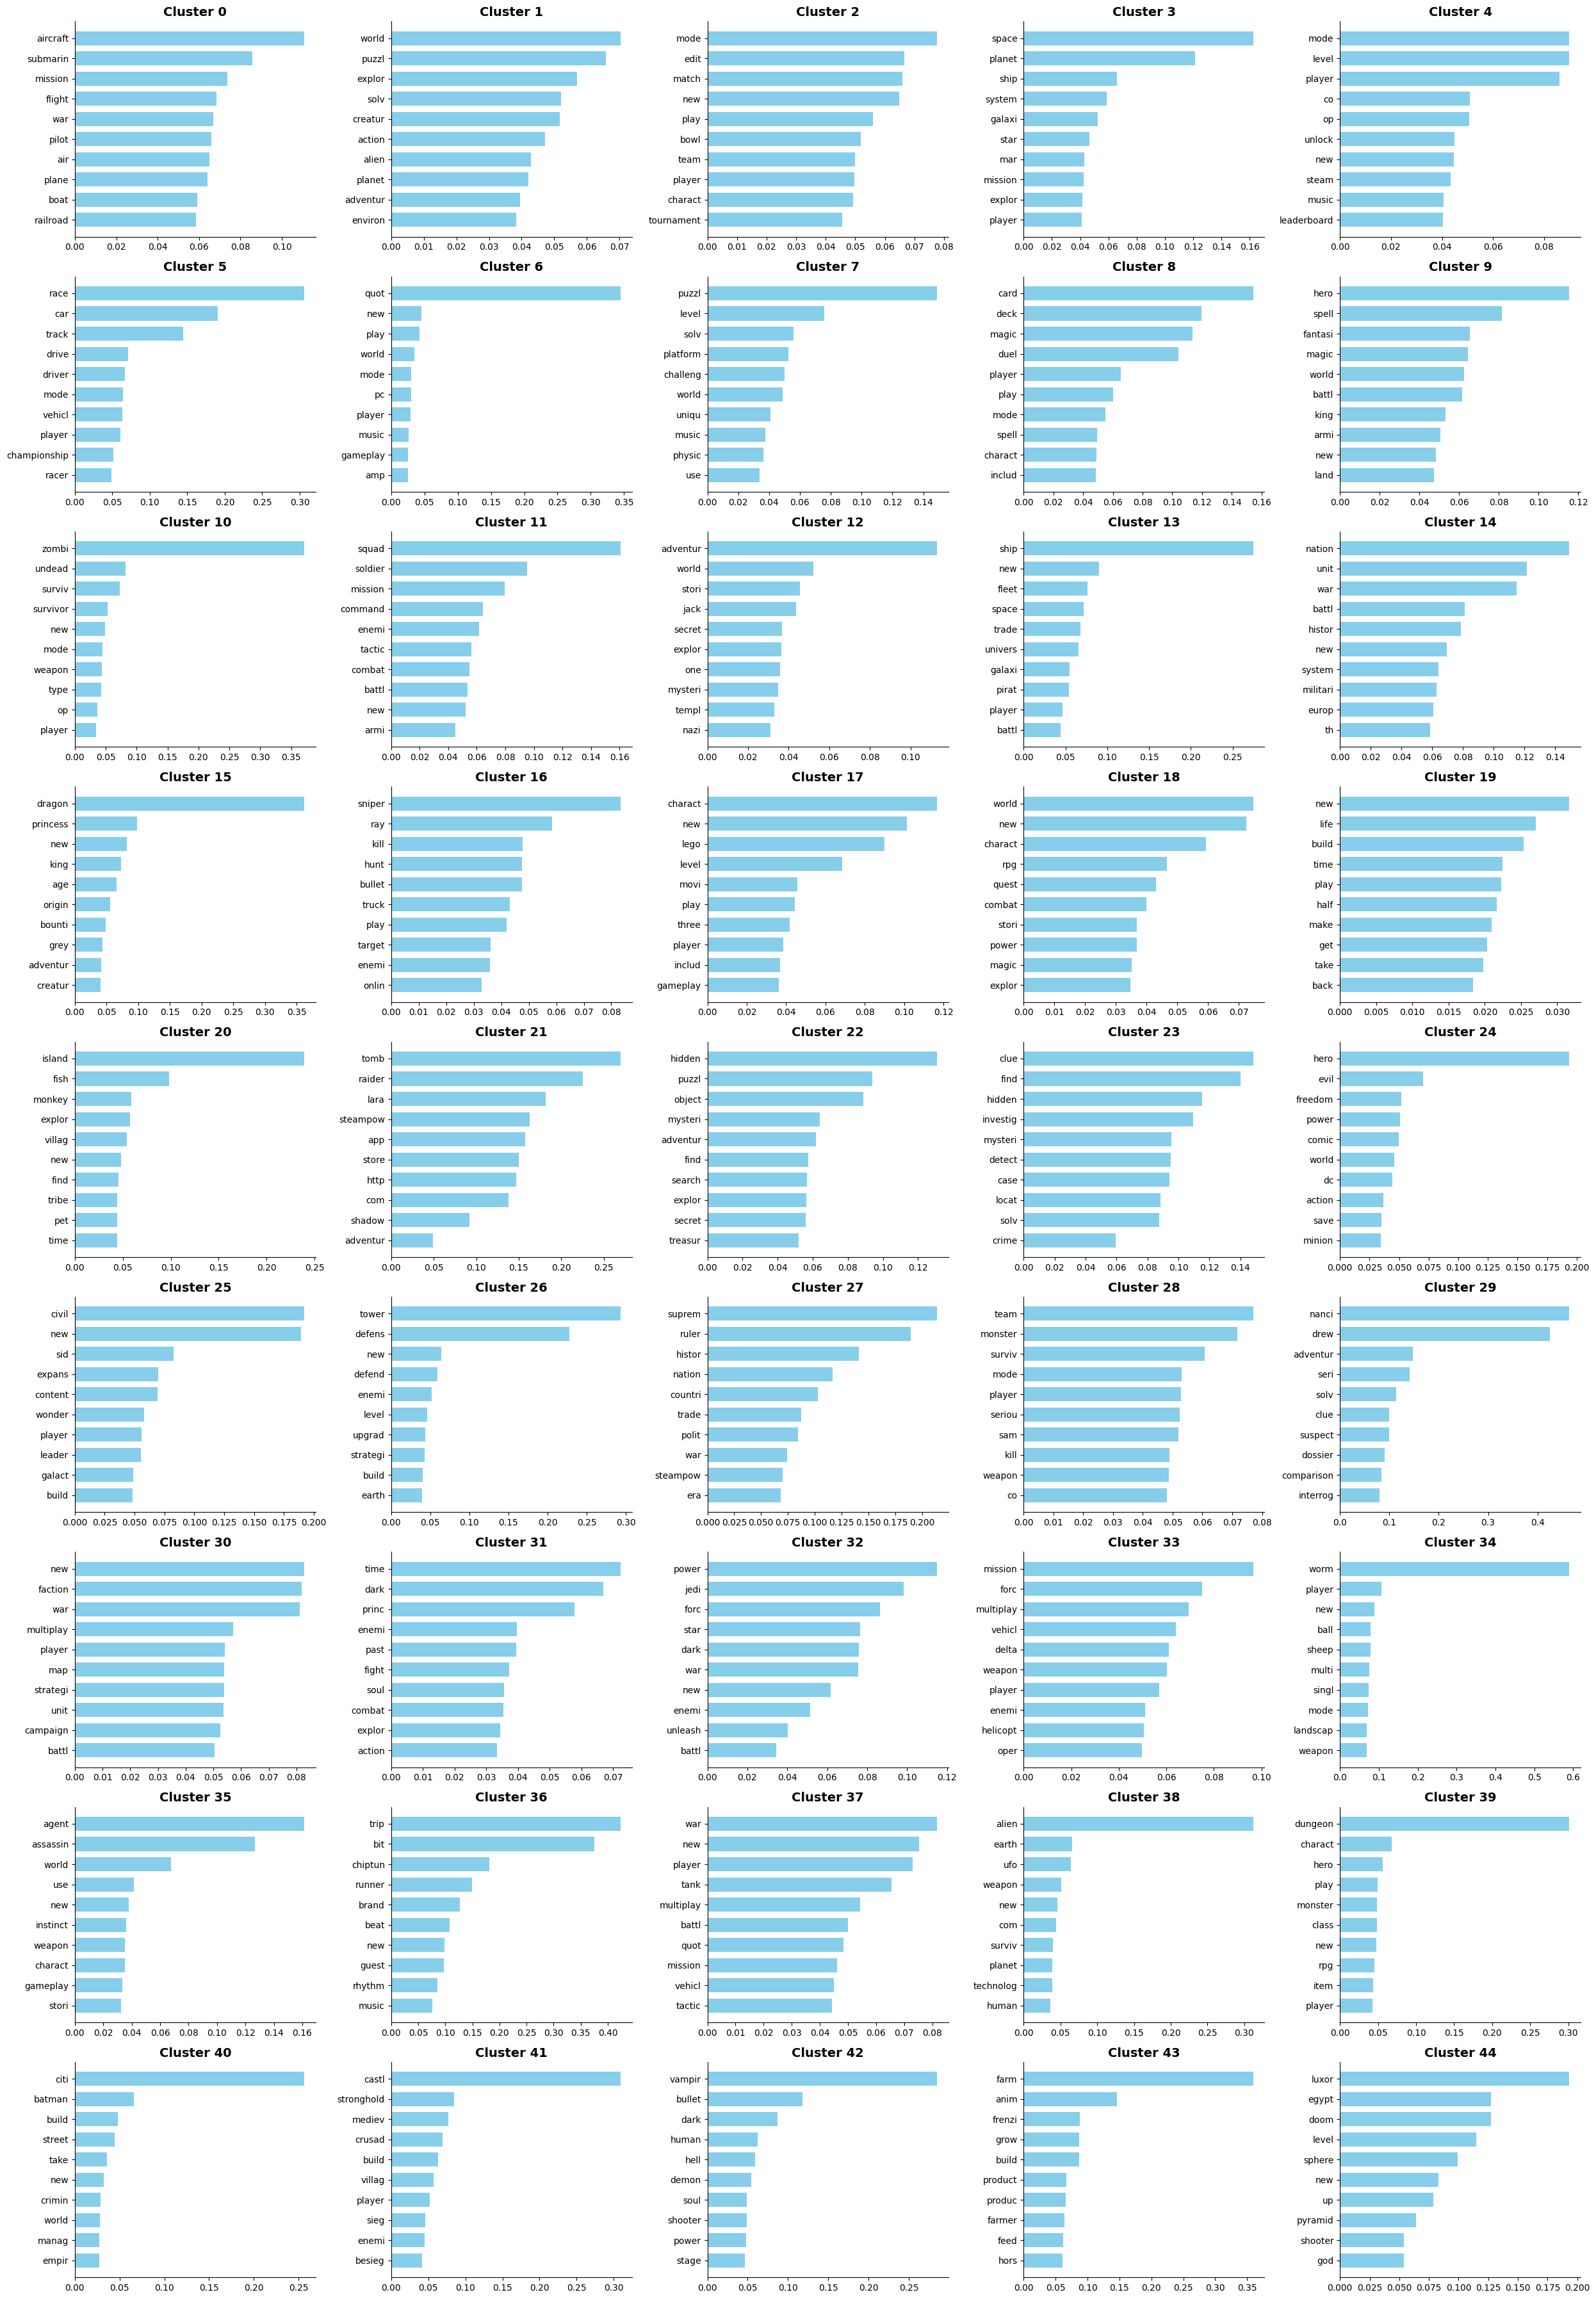

In [24]:
import matplotlib.pyplot as plt
import numpy as np
#mostra grafico de barras com as palavras(gemini)
def plot_kmeans_top_words(centroids, feature_names, n_top_words=10):
    n_clusters = centroids.shape[0]
    # Grid de 9 linhas x 5 colunas para caber 45 clusters
    rows = int(np.ceil(n_clusters / 5))
    cols = 5
    
    fig, axes = plt.subplots(rows, cols, figsize=(25, 4 * rows), sharex=False)
    axes = axes.flatten()

    for i in range(n_clusters):
        # Pegar os índices das palavras mais importantes (do maior para o menor)
        top_indices = centroids[i].argsort()[::-1][:n_top_words]
        top_words = [feature_names[ind] for ind in top_indices]
        top_weights = centroids[i][top_indices]
        
        ax = axes[i]
        # Plotar
        ax.barh(top_words, top_weights, height=0.7, color='skyblue')
        ax.set_title(f"Cluster {i}", fontsize=14, fontweight='bold')
        ax.invert_yaxis() # Palavra mais importante no topo
        ax.tick_params(axis='both', labelsize=10)
        
        # Limpar visual
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)

    # Remover subplots vazios se houver
    for i in range(n_clusters, len(axes)):
        fig.delaxes(axes[i])

    plt.tight_layout()
    plt.show()

# Chamada da função com seus dados
plot_kmeans_top_words(original_space_centroids, terms)

In [23]:
#Agrupamento aglomerativo
from sklearn.cluster import AgglomerativeClustering

range_cluster=range(43, 47)

for n_clusters in range_cluster:
    clusterer = AgglomerativeClustering(n_clusters=45,linkage='ward',metric='euclidean')
    cluster_labels = clusterer.fit_predict(final_matrix)

    # The silhouette_score gives the average value for all the samples.
    # This gives a perspective into the density and separation of the formed
    # clusters
    silhouette_avg = silhouette_score(final_matrix, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "The average silhouette_score is :",
        silhouette_avg,
    )



For n_clusters = 43 The average silhouette_score is : 0.013230439947202249
For n_clusters = 44 The average silhouette_score is : 0.013230439947202249
For n_clusters = 45 The average silhouette_score is : 0.013230439947202249


KeyboardInterrupt: 